# 🧠 EEG Klasterizavimo Analizė: Alzheimerio liga · FTD · Kontrolė

> **Bakalauro darbas** | Kauno technologijų universitetas
> **Tikslas:** įvertinti elektroencefalogramos (EEG) signalų dimensijų mažinimo ir klasterizavimo metodus.

---

## 🗂️ Duomenų rinkinys

| Grupė | Kodas | Aprašymas |
|-------|-------|-----------|
| Alzheimerio liga | `A` | Demencija su atminties sutrikimais |
| Frontotemporalinė demencija | `F` | Demencija su elgesio/kalbos sutrikimais |
| Kontrolė | `C` | Sveiki tiriamieji |

**Iš viso:** 88 tiriamieji · **Formatas:** `.set` (EEGLAB) · **Dažnis:** 256 Hz


---
## 1. Aplinkos Paruošimas

Importuojamos visos reikalingos bibliotekos ir įkeliami duomenys.

| Biblioteka | Paskirtis |
|------------|----------|
| `mne` | EEG signalų nuskaitymas ir apdorojimas |
| `numpy` / `pandas` | Skaitiniai skaičiavimai, lentelės |
| `scipy` | Statistiniai požymiai, PSD |
| `sklearn` | Klasterizavimas, PCA, vertinimas |
| `matplotlib` / `seaborn` | Vizualizacija |


In [1]:
# Importuojamos visos reikalingos bibliotekos:
# mne - EEG signalų apdorojimui
# numpy, pandas - skaitiniams skaičiavimams ir duomenų valdymui
# scipy - statistiniams požymiams ir signalų analizei
# sklearn - klasterizavimui, dimensijų mažinimui ir vertinimui
# matplotlib, seaborn - vizualizacijai
import mne
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import skew, kurtosis, iqr, entropy, median_abs_deviation
from scipy.signal import find_peaks
from scipy.integrate import trapezoid

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix, accuracy_score, jaccard_score, silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from scipy.optimize import linear_sum_assignment

print('Bibliotekos įkeltos.')

Bibliotekos įkeltos.


In [2]:
# Ieškoma visų .set formato EEG failų dabartiniame kataloge
# Įkeliami tiriamųjų metaduomenys (grupės, demografija) iš TSV failo
files = glob.glob('*.set')
print('Rasta failų:', len(files))

df_meta = pd.read_csv('participants.tsv', sep='\t')
print(df_meta.head())
print('Grupės:', df_meta['Group'].value_counts().to_dict())

Rasta failų: 88
  participant_id Gender  Age Group  MMSE
0        sub-001      F   57     A    16
1        sub-002      F   78     A    22
2        sub-003      M   70     A    14
3        sub-004      F   67     A    20
4        sub-005      M   70     A    22
Grupės: {'A': 36, 'C': 29, 'F': 23}


---
## 2. Artefaktų Valymas

Daugiapakopis EEG signalų valymo pipeline, pritaikytas **užmerktų akių** (*eyes-closed*) ramybės būsenos duomenims.

### Pipeline žingsniai

```
Žalio signalo įkėlimas
        ↓
1. Bandpass filtras (1–40 Hz, FIR Hamming)
        ↓
2. Notch filtras (50 Hz — elektros tinklo triukšmas)
        ↓
3. Blogų kanalų detekcija (dispersijos kriterijus) + interpoliacija
        ↓
4. Vidutinis referencijavimas (average reference)
        ↓
5. Epochų pjovimas (4 s) + amplitudės atmetimas (±200 µV)
        ↓
Išvalyti duomenys [kanalai × laikas]
```


In [ ]:
# Artefaktų valymo funkcija:
# 1. Kopijuojamas originalus signalas, kad nebūtų pakeisti originalūs duomenys
# 2. Taikomas juostos pralaidumo filtras (1-40 Hz) ir notch filtras (50 Hz)
# 3. Priskiriamas standartinis 10-20 elektrodų išdėstymo planas
# 4. Skaičiuojama kiekvieno kanalo dispersija — blogi kanalai identifikuojami
#    pagal 10x didesnę arba 0.1x mažesnę dispersiją nei mediana
# 5. Blogi kanalai interpoliuojami iš gretimų elektrodų
# 6. Taikomas vidutinis referencijavimas
# 7. Signalas suskaidomas į 4 sekundžių epochas
# 8. Atmestos epochos viršijančios 200 µV arba žemiau 1e-8 V
# 9. Jei visos epochos atmestos — slenkstis padidinamas iki 400 µV
# 10. Grąžinami išvalyti duomenys, kanalų pavadinimai ir dažnis
def clean_raw(raw, notch_freq=50):
    """
    Artefaktų valymo pipeline optimizuotas eyes-closed EEG.
    ICA nenaudojamas: eyes-closed duomenyse mirksėjimų minimaliai,
    nėra EOG elektrodų, ICA rizikuoja pašalinti alfa komponentus.

    Žingsniai:
      1. Bandpass filtras (1-40 Hz)
      2. Notch filtras (50 Hz)
      3. Blogų kanalų detekcija ir interpoliacija
      4. Vidutinis referencijavimas
      5. Amplitudės atmetimas (200 µV, 4 sekundžių epochos)
    """
    raw = raw.copy()

    # Žingsnis 1 & 2: Filtravimas
    raw.filter(l_freq=1.0, h_freq=40.0, method='fir', fir_window='hamming', verbose=False)
    raw.notch_filter(freqs=notch_freq, verbose=False)

    # Žingsnis 3: Blogų kanalų detekcija (variacija)
    raw.set_montage('standard_1020', on_missing='ignore', verbose=False)
    data_check = raw.get_data()
    ch_vars = np.var(data_check, axis=1)
    med_var = np.median(ch_vars)
    bad_mask = (ch_vars > 10 * med_var) | (ch_vars < 0.1 * med_var)
    bad_chs = [raw.ch_names[i] for i, b in enumerate(bad_mask) if b]

    if bad_chs:
        raw.info['bads'] = bad_chs
        raw.interpolate_bads(reset_bads=True, verbose=False)
        print(f'  Interpoliuoti blogų kanalai: {bad_chs}')
    else:
        print('  Blogų kanalų nerasta.')

    # Žingsnis 4: Vidutinis referencijavimas
    raw.set_eeg_reference('average', projection=True, verbose=False)
    raw.apply_proj(verbose=False)

    # Žingsnis 5: Amplitudės atmetimas (4 sekundžių epochos, 200 µV)
    events = mne.make_fixed_length_events(raw, duration=4.0)
    epochs = mne.Epochs(
        raw, events,
        tmin=0, tmax=4.0,
        baseline=None,
        reject={'eeg': 200e-6},
        flat={'eeg': 1e-8},
        verbose=False,
        preload=True,
    )

    if len(epochs) == 0:
        print('  ĮSPĖJIMAS: Visos epochos atmestos — atleidžiama iki 400 µV')
        epochs = mne.Epochs(raw, events, tmin=0, tmax=4.0,
                            baseline=None, reject={'eeg': 400e-6},
                            verbose=False, preload=True)

    pct_kept = len(epochs) / len(events) * 100
    print(f'  Epochos: {len(epochs)}/{len(events)}  ({pct_kept:.0f}%)')

    clean = epochs.get_data()
    clean = clean.transpose(1, 0, 2)
    clean = clean.reshape(clean.shape[0], -1)
    return clean, raw.ch_names, raw.info['sfreq']

---
## 3. Požymių Išgavimas

Kiekvienam EEG kanalui išskaičiuojami **15 požymių**, apimantys laiko ir dažnių sritis.


In [ ]:
# Požymių išgavimo funkcija vienam kanalui:
# Tikrinama ar signalas pakankamai ilgas (min. 1 sekundė)
# eps - mažas skaičius dalybyos iš nulio išvengimui
# Skaičiuojami laiko srities požymiai: vidurkis, standartinis nuokrypis
# Skaičiuojami formos požymiai: asimetrija ir ekscesas
# Entropija skaičiuojama iš histogramos (50 intervalų)
# Skaičiuojami nuliniai kirtimai ir pikų skaičius
# PSD skaičiuojamas Welch metodu (4s langas, 2s persidengimas)
# Apskaičiuojama santykinė galia delta/teta/alfa/beta juostose
# Skaičiuojamas medianinis dažnis ir SEF95 spektrinio poslinkio vertinimui
# Hjorth judumas ir sudėtingumas skaičiuojami iš pirmosios ir antrosios išvestinių
import numpy as np
from scipy.stats import skew, kurtosis, entropy
from scipy.signal import find_peaks
import mne
from scipy.integrate import trapezoid
from scipy.stats import median_abs_deviation, iqr


def extract_features(signal, sfreq=256):
    signal = np.asarray(signal, dtype=np.float64)

    if len(signal) < sfreq:
        return {}

    eps = 1e-10

    # -----------------------
    # BASIC STATS (minimal)
    # -----------------------
    mean_val = np.mean(signal)
    std_val = np.std(signal) + eps

    # -----------------------
    # ROBUST VARIABILITY
    # -----------------------
    skew_val = skew(signal, bias=False)
    kurt_val = kurtosis(signal, fisher=True, bias=False)

    # -----------------------
    # NONLINEAR (simple entropy)
    # -----------------------
    hist, _ = np.histogram(signal, bins=50, density=True)
    hist = hist[hist > 0]
    entropy_val = entropy(hist)

    # -----------------------
    # ZERO-CROSSINGS (kept only one)
    # -----------------------
    zero_crossings = np.sum(np.diff(np.sign(signal)) != 0)

    # -----------------------
    # PEAK ACTIVITY (optional but stable)
    # -----------------------
    peaks, _ = find_peaks(signal)
    num_peaks = len(peaks)

    # -----------------------
    # PSD (EEG core)
    # -----------------------
    psd, freqs = mne.time_frequency.psd_array_welch(
        signal[np.newaxis, :],
        sfreq=sfreq,
        fmin=1.0,
        fmax=40.0,
        n_fft=int(sfreq * 4),
        n_overlap=int(sfreq * 2),
        verbose=False,
    )

    psd = np.squeeze(psd)
    total_power = trapezoid(psd, freqs) + eps

    def band(fmin, fmax):
        idx = (freqs >= fmin) & (freqs <= fmax)
        return trapezoid(psd[idx], freqs[idx])

    delta = band(1, 4)
    theta = band(4, 8)
    alpha = band(8, 13)
    beta  = band(13, 30)

    # -----------------------
    # RELATIVE POWERS (IMPORTANT FOR CLUSTERING)
    # -----------------------
    delta_rel = delta / total_power
    theta_rel = theta / total_power
    alpha_rel = alpha / total_power
    beta_rel  = beta / total_power

    # -----------------------
    # SPECTRAL FEATURES (EEG slowing)
    # -----------------------
    cum_psd = np.cumsum(psd)

    median_freq = freqs[np.searchsorted(cum_psd, 0.5 * cum_psd[-1])]
    sef95 = freqs[np.searchsorted(cum_psd, 0.95 * cum_psd[-1])]

    # -----------------------
    # HJORTH (KEEP ONLY 2 MOST IMPORTANT)
    # -----------------------
    dx = np.diff(signal)

    activity = np.var(signal)
    mobility = np.sqrt(np.var(dx) / (activity + eps))

    ddx = np.diff(dx)
    complexity = np.sqrt(np.var(ddx) / (np.var(dx) + eps)) / (mobility + eps)

    return {
        # basic
        "mean": mean_val,
        "std": std_val,

        # shape
        "skewness": skew_val,
        "kurtosis": kurt_val,

        # complexity
        "entropy": entropy_val,
        "hjorth_mobility": mobility,
        "hjorth_complexity": complexity,

        # morphology
        "zero_crossings": zero_crossings,
        "num_peaks": num_peaks,

        # spectral (MOST IMPORTANT)
        "delta_rel": delta_rel,
        "theta_rel": theta_rel,
        "alpha_rel": alpha_rel,
        "beta_rel": beta_rel,

        # spectral shift
        "median_freq": median_freq,
        "sef95": sef95,
    }

---
## 4. Duomenų Apdorojimas

Kiekvienas `.set` failas apdorojamas nuosekliai — valomas, išgaunami požymiai ir sujungiami į vieną požymių matricą.

**Rezultatas:** `EEG_Features_fixed.csv` — viena eilutė vienam tiriamajam, stulpeliai: `{kanalas}_{požymis}`.


In [ ]:
# Pagrindinis apdorojimo ciklas:
# Kiekvienas .set failas įkeliamas naudojant MNE
# Atliekamas artefaktų valymas per clean_raw funkciją
# Kiekvienam kanalui išskaičiuojami požymiai per extract_features
# Požymiai saugomi kaip viena eilutė vienam tiriamajam
# Galutinė požymių matrica išsaugoma į CSV failą
all_features = []

for file in files:
    print(f'\nApdorojamas: {file}')
    try:
        raw = mne.io.read_raw_eeglab(file, preload=True, verbose=False)
    except Exception as e:
        print(f'  KLAIDA įkeliant: {e}')
        continue

    try:
        clean_data, ch_names, sfreq = clean_raw(raw)
    except Exception as e:
        print(f'  KLAIDA valant: {e} — praleidžiama')
        continue

    subject_row = {'file': file}
    for i, ch in enumerate(ch_names):
        feats = extract_features(clean_data[i], sfreq=sfreq)
        for k, v in feats.items():
            subject_row[f'{ch}_{k}'] = v

    all_features.append(subject_row)

df = pd.DataFrame(all_features)
print(f'\nPožymių matrica: {df.shape}')
df.to_csv('EEG_Features_fixed.csv', index=False)
print('Išsaugota į EEG_Features_fixed.csv')

---
## 5. Kanalų Agregavimas (F ir O regionai)

Siekiant sumažinti dimensiją ir išryškinti biologiškai prasmingas charakteristikas, atskirų kanalų požymiai agreguojami į **regioninius rodiklius**.

| Regionas | Kanalai | Agreguojama |
|----------|---------|-------------|
| Frontalinis (F) | Fp1, Fp2, F3, F4, F7, F8, Fz | Vidurkis |
| Okcipitalinis (O) | O1, O2, Oz | Vidurkis + std |
| Skirtumas | O − F | Kiekvienam požymiui |

> 💡 **Kodėl O−F skirtumas?** AD ir FTD skirtingai veikia frontalines ir pakaušines smegenų sritis, todėl jų skirtumas gali būti informatyvus klasifikavimui.


In [7]:
# Frontalinių (F) ir okcipitalinių (O) kanalų agregavimas:
# Apibrėžiami frontaliniai kanalai: Fp1, Fp2, F3, F4, F7, F8, Fz
# Apibrėžiami okcipitaliniai kanalai: O1, O2, Oz
# Sąrašas visų 15 požymių kurie bus agreguojami
# ============================================
# F ir O kanalų požymių suvidurkinimas
# ============================================
df = pd.read_csv("EEG_Features_fixed.csv")
F_channels = ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz']
O_channels = ['O1', 'O2', 'Oz']

# --------------------------------------------
# Visų požymių pavadinimai
# --------------------------------------------

features = [
    "mean",
    "std",
    "skewness",
    "kurtosis",
    "entropy",
    "hjorth_mobility",
    "hjorth_complexity",
    "zero_crossings",
    "num_peaks",
    "delta_rel",
    "theta_rel",
    "alpha_rel",
    "beta_rel",
    "median_freq",
    "sef95",
]

# ============================================
# Naujas dataframe agreguotiems požymiams
# ============================================

aggregated_df = pd.DataFrame()
aggregated_df['file'] = df['file']

# ============================================
# Skaičiuojame F ir O mean/std
# ============================================

for feat in features:

    # -------------------------
    # Frontaliniai kanalai
    # -------------------------
    F_cols = [
        f'{ch}_{feat}'
        for ch in F_channels
        if f'{ch}_{feat}' in df.columns
    ]

    if len(F_cols) > 0:
        aggregated_df[f'F_mean_{feat}'] = df[F_cols].mean(axis=1)
       # aggregated_df[f'F_std_{feat}'] = df[F_cols].std(axis=1)

    # -------------------------
    # Okcipitaliniai kanalai
    # -------------------------
    O_cols = [
        f'{ch}_{feat}'
        for ch in O_channels
        if f'{ch}_{feat}' in df.columns
    ]

    if len(O_cols) > 0:
        aggregated_df[f'O_mean_{feat}'] = df[O_cols].mean(axis=1)
        aggregated_df[f'O_std_{feat}'] = df[O_cols].std(axis=1)

    # -------------------------
    # Skirtumas O - F
    # -------------------------
    if len(F_cols) > 0 and len(O_cols) > 0:
        aggregated_df[f'DIFF_{feat}'] = (
            aggregated_df[f'O_mean_{feat}']
            - aggregated_df[f'F_mean_{feat}']
        )
# ============================================
# Rezultatas
# ============================================

print("Agreguotos matricos dydis:", aggregated_df.shape)

aggregated_df.to_csv(
    'EEG_Features_F_O_Aggregated.csv',
    index=False
)

print("Išsaugota: EEG_Features_F_O_Aggregated.csv")

Agreguotos matricos dydis: (88, 61)
Išsaugota: EEG_Features_F_O_Aggregated.csv


In [8]:
# Kiekvienam požymiui skaičiuojamas:
# F_mean - frontalinių kanalų vidurkis
# O_mean - okcipitalinių kanalų vidurkis
# O_std  - okcipitalinių kanalų standartinis nuokrypis
# DIFF   - skirtumas tarp okcipitalinio ir frontalinio vidurkio
# Agreguotas rezultatas išsaugomas į atskirą CSV failą
final_df = df.copy()

# ============================================
# Pašaliname F ir O kanalų požymius
# ============================================

channels_to_remove = F_channels + O_channels

cols_to_drop = []

for ch in channels_to_remove:
    for feat in features:
        col = f"{ch}_{feat}"
        if col in final_df.columns:
            cols_to_drop.append(col)

final_df.drop(columns=cols_to_drop, inplace=True)

# ============================================
# Pridedame agreguotas reikšmes
# ============================================

agg_cols = [col for col in aggregated_df.columns if col != 'file']

final_df = final_df.merge(
    aggregated_df[['file'] + agg_cols],
    on='file',
    how='left'
)

print("Agreguotos matricos dydis:", final_df.shape)
print("Stulpeliai:", final_df.columns.tolist())
# ============================================
# Išsaugojimas
# ============================================

final_df.to_csv(
    'EEG_Features_Final.csv',
    index=False
)

print("Išsaugota: EEG_Features_Final.csv")

Agreguotos matricos dydis: (88, 211)
Stulpeliai: ['file', 'C3_mean', 'C3_std', 'C3_skewness', 'C3_kurtosis', 'C3_entropy', 'C3_hjorth_mobility', 'C3_hjorth_complexity', 'C3_zero_crossings', 'C3_num_peaks', 'C3_delta_rel', 'C3_theta_rel', 'C3_alpha_rel', 'C3_beta_rel', 'C3_median_freq', 'C3_sef95', 'C4_mean', 'C4_std', 'C4_skewness', 'C4_kurtosis', 'C4_entropy', 'C4_hjorth_mobility', 'C4_hjorth_complexity', 'C4_zero_crossings', 'C4_num_peaks', 'C4_delta_rel', 'C4_theta_rel', 'C4_alpha_rel', 'C4_beta_rel', 'C4_median_freq', 'C4_sef95', 'P3_mean', 'P3_std', 'P3_skewness', 'P3_kurtosis', 'P3_entropy', 'P3_hjorth_mobility', 'P3_hjorth_complexity', 'P3_zero_crossings', 'P3_num_peaks', 'P3_delta_rel', 'P3_theta_rel', 'P3_alpha_rel', 'P3_beta_rel', 'P3_median_freq', 'P3_sef95', 'P4_mean', 'P4_std', 'P4_skewness', 'P4_kurtosis', 'P4_entropy', 'P4_hjorth_mobility', 'P4_hjorth_complexity', 'P4_zero_crossings', 'P4_num_peaks', 'P4_delta_rel', 'P4_theta_rel', 'P4_alpha_rel', 'P4_beta_rel', 'P4_medi

Stulpeliai: ['file', 'C3_mean', 'C3_std', 'C3_skewness', 'C3_kurtosis', 'C3_entropy', 'C3_hjorth_mobility', 'C3_hjorth_complexity', 'C3_zero_crossings', 'C3_num_peaks', 'C3_delta_rel', 'C3_theta_rel', 'C3_alpha_rel', 'C3_beta_rel', 'C3_median_freq', 'C3_sef95', 'C4_mean', 'C4_std', 'C4_skewness', 'C4_kurtosis', 'C4_entropy', 'C4_hjorth_mobility', 'C4_hjorth_complexity', 'C4_zero_crossings', 'C4_num_peaks', 'C4_delta_rel', 'C4_theta_rel', 'C4_alpha_rel', 'C4_beta_rel', 'C4_median_freq', 'C4_sef95', 'P3_mean', 'P3_std', 'P3_skewness', 'P3_kurtosis', 'P3_entropy', 'P3_hjorth_mobility', 'P3_hjorth_complexity', 'P3_zero_crossings', 'P3_num_peaks', 'P3_delta_rel', 'P3_theta_rel', 'P3_alpha_rel', 'P3_beta_rel', 'P3_median_freq', 'P3_sef95', 'P4_mean', 'P4_std', 'P4_skewness', 'P4_kurtosis', 'P4_entropy', 'P4_hjorth_mobility', 'P4_hjorth_complexity', 'P4_zero_crossings', 'P4_num_peaks', 'P4_delta_rel', 'P4_theta_rel', 'P4_alpha_rel', 'P4_beta_rel', 'P4_median_freq', 'P4_sef95', 'T3_mean', 'T3_

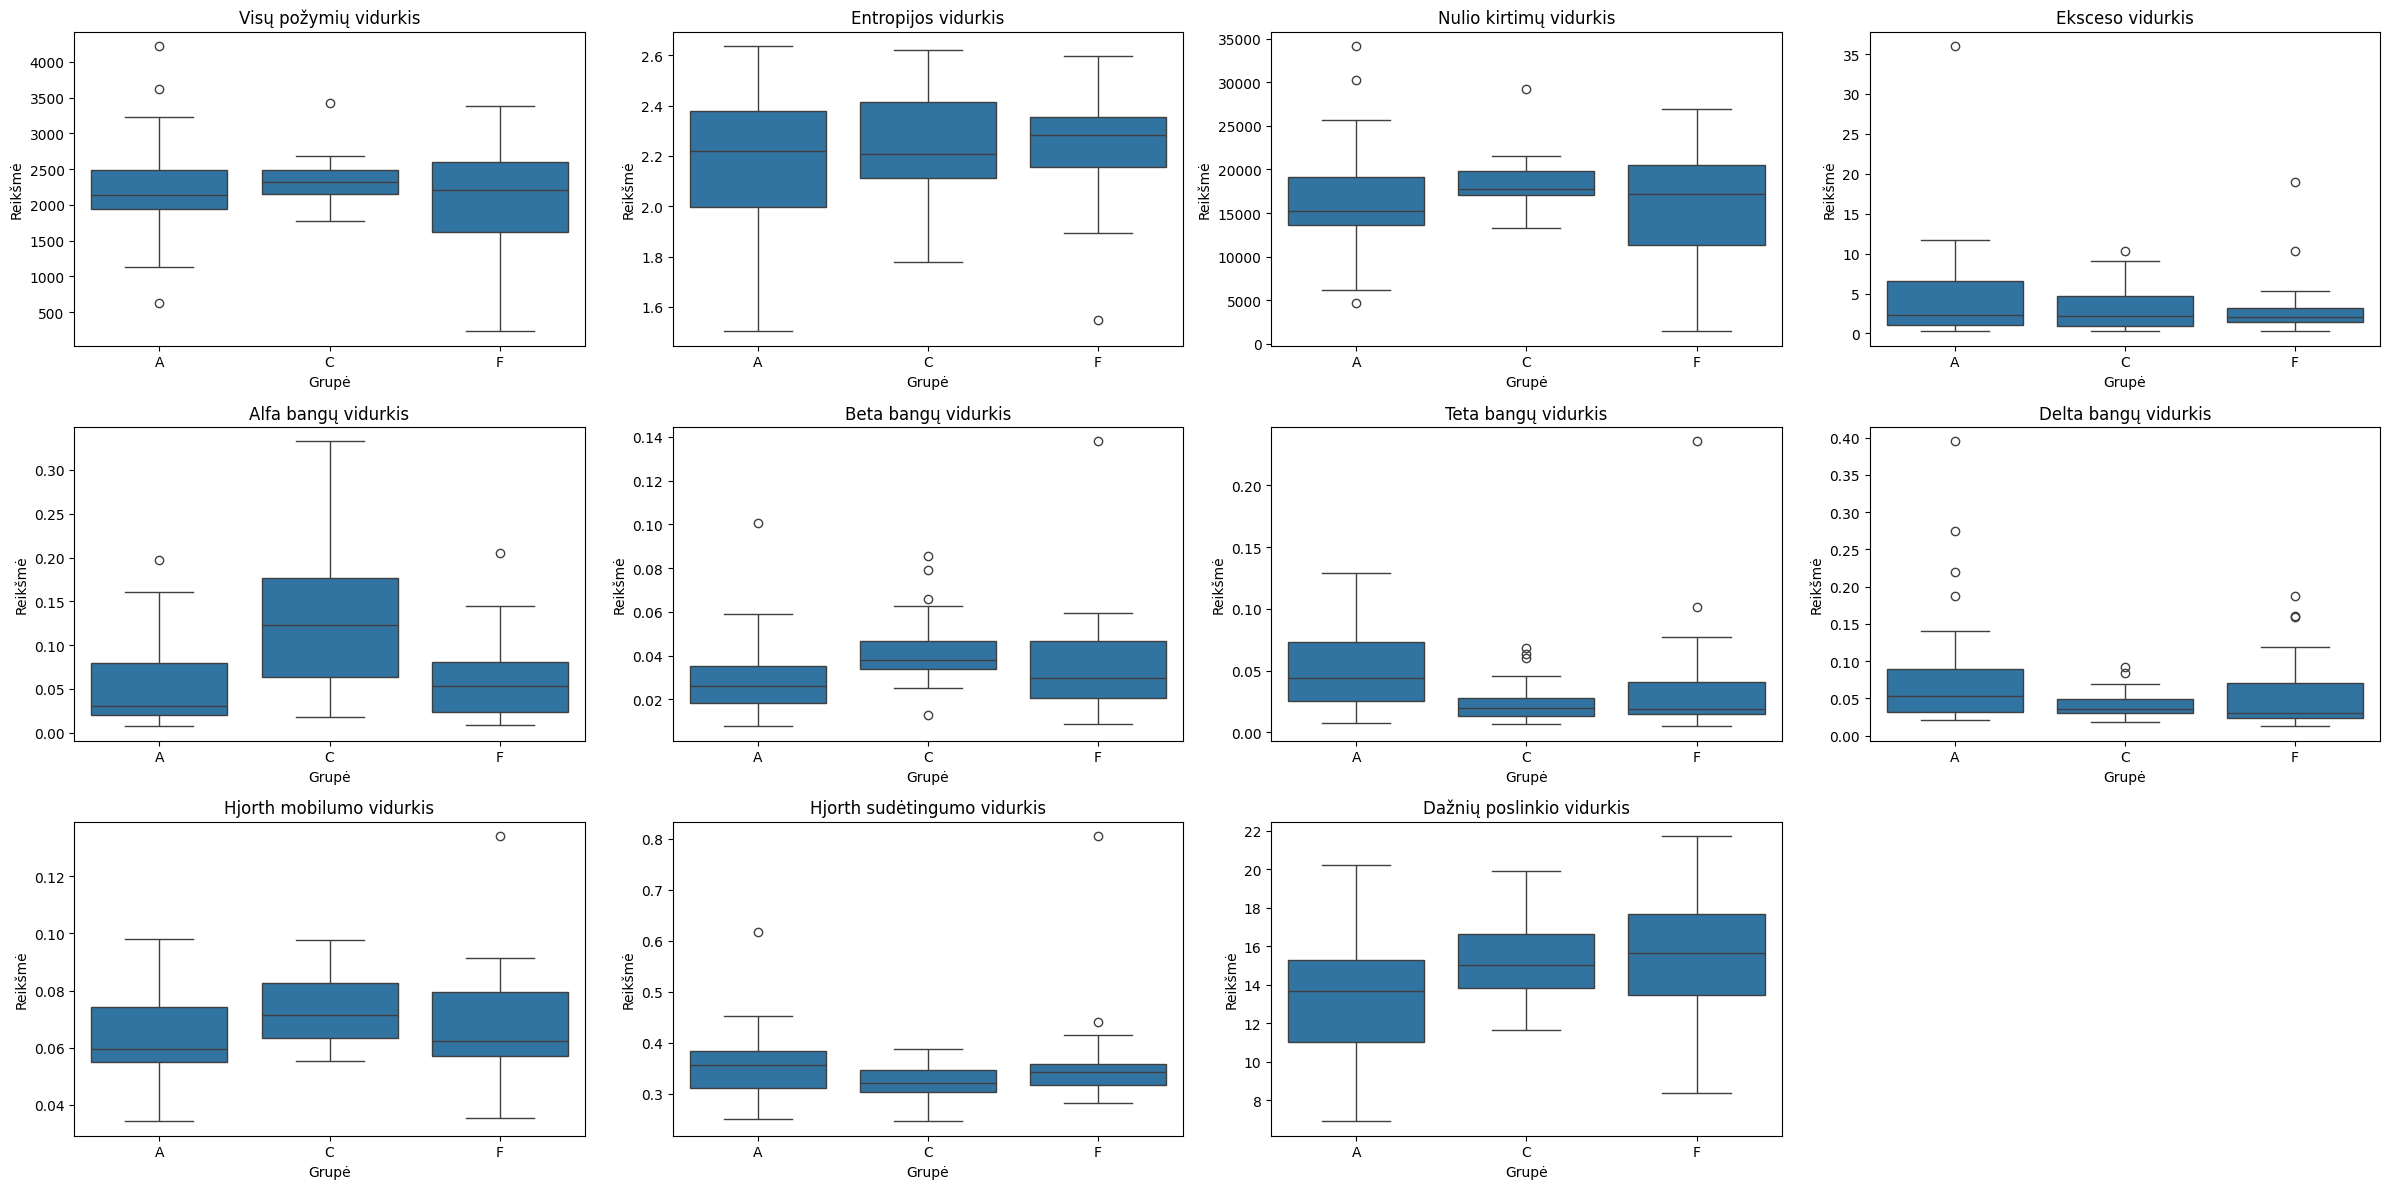

In [9]:
# Originalūs F ir O kanalų stulpeliai pašalinami iš matricos
# Agreguotos reikšmės prijungiamos prie likusių kanalų požymių
# Galutinė matrica išsaugoma kaip EEG_Features_Final.csv
# Įkeliame agreguotą failą
df = pd.read_csv("EEG_Features_Final.csv").reset_index(drop=True)

# Prijungiame metaduomenis (įsitikiname kad indeksai sutampa)
df_meta = df_meta.reset_index(drop=True)
df = pd.concat([df, df_meta], axis=1)

# Valome Group stulpelį
df = df.dropna(subset=["Group"])
df["Group"] = df["Group"].astype(str)

print("Stulpeliai:", df.columns.tolist())
print("Grupių reikšmės:", df["Group"].value_counts())

# Požymių sąrašas
feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in ["Group", "file"]:
    if col in feature_cols:
        feature_cols.remove(col)

# Susumuoti požymiai
df["all_features_mean"]      = df[feature_cols].mean(axis=1)
df["entropy_mean"]           = df[[c for c in feature_cols if "entropy" in c]].mean(axis=1)

df["rms_mean"] = (
    df[[c for c in feature_cols if "rms" in c]].mean(axis=1)
    if any("rms" in c for c in feature_cols)
    else np.nan
)

df["zero_crossings_mean"]    = df[[c for c in feature_cols if "zero_crossings" in c]].mean(axis=1)
df["kurtosis_mean"]          = df[[c for c in feature_cols if "kurtosis" in c]].mean(axis=1)
df["alpha_mean"]             = df[[c for c in feature_cols if "alpha_rel" in c]].mean(axis=1)
df["beta_mean"]              = df[[c for c in feature_cols if "beta_rel" in c]].mean(axis=1)
df["theta_mean"]             = df[[c for c in feature_cols if "theta_rel" in c]].mean(axis=1)
df["delta_mean"]             = df[[c for c in feature_cols if "delta_rel" in c]].mean(axis=1)

df["hjorth_mobility_mean"] = (
    df[[c for c in feature_cols if "hjorth_mobility" in c]].mean(axis=1)
)

df["hjorth_complexity_mean"] = (
    df[[c for c in feature_cols if "hjorth_complexity" in c]].mean(axis=1)
)

df["ratio_mean"] = (
    df[[c for c in feature_cols if "ratio" in c]].mean(axis=1)
    if any("ratio" in c for c in feature_cols)
    else np.nan
)

df["freq_shift_mean"] = (
    df[[c for c in feature_cols if ("median_freq" in c or "sef95" in c)]]
    .mean(axis=1)
)

features_to_plot = [
    "all_features_mean",
    "entropy_mean",
    "rms_mean",
    "zero_crossings_mean",
    "kurtosis_mean",
    "alpha_mean",
    "beta_mean",
    "theta_mean",
    "delta_mean",
    "hjorth_mobility_mean",
    "hjorth_complexity_mean",
    "freq_shift_mean",
]

# Lietuviški pavadinimai
feature_names_lt = {
    "all_features_mean": "Visų požymių vidurkis",
    "entropy_mean": "Entropijos vidurkis",
    "rms_mean": "RMS vidurkis",
    "zero_crossings_mean": "Nulio kirtimų vidurkis",
    "kurtosis_mean": "Eksceso vidurkis",
    "alpha_mean": "Alfa bangų vidurkis",
    "beta_mean": "Beta bangų vidurkis",
    "theta_mean": "Teta bangų vidurkis",
    "delta_mean": "Delta bangų vidurkis",
    "hjorth_mobility_mean": "Hjorth mobilumo vidurkis",
    "hjorth_complexity_mean": "Hjorth sudėtingumo vidurkis",
    "freq_shift_mean": "Dažnių poslinkio vidurkis",
}

# Pašaliname požymius kurie visi NaN
features_to_plot = [f for f in features_to_plot if df[f].notna().any()]

# Dinaminis subplot skaičius
ncols = 4
nrows = (len(features_to_plot) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(24, nrows * 4))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):

    # Pašaliname NaN tik šiam požymiui
    plot_df = df[["Group", feat]].dropna()

    sns.boxplot(
        data=plot_df,
        x="Group",
        y=feat,
        ax=axes[i]
    )

    # Lietuviški pavadinimai
    axes[i].set_title(feature_names_lt.get(feat, feat), fontsize=12)

    axes[i].set_xlabel("Grupė")
    axes[i].set_ylabel("Reikšmė")

# Paslepiame tuščius subplot'us
for j in range(len(features_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---
## 6. Požymių Analizė Grupėse

Vizualiai lyginamas kiekvieno požymio pasiskirstymas tarp trijų grupių naudojant box plot diagramas.


['C3_hjorth_mobility', 'C3_hjorth_complexity', 'C3_delta_rel', 'C3_theta_rel', 'C3_alpha_rel', 'C3_beta_rel', 'C3_median_freq', 'C3_sef95', 'C4_hjorth_mobility', 'C4_hjorth_complexity', 'C4_delta_rel', 'C4_theta_rel', 'C4_alpha_rel', 'C4_beta_rel', 'C4_median_freq', 'C4_sef95', 'P3_hjorth_mobility', 'P3_hjorth_complexity', 'P3_delta_rel', 'P3_theta_rel', 'P3_alpha_rel', 'P3_beta_rel', 'P3_median_freq', 'P3_sef95', 'P4_hjorth_mobility', 'P4_hjorth_complexity', 'P4_delta_rel', 'P4_theta_rel', 'P4_alpha_rel', 'P4_beta_rel', 'P4_median_freq', 'P4_sef95', 'T3_hjorth_mobility', 'T3_hjorth_complexity', 'T3_delta_rel', 'T3_theta_rel', 'T3_alpha_rel', 'T3_beta_rel', 'T3_median_freq', 'T3_sef95', 'T4_hjorth_mobility', 'T4_hjorth_complexity', 'T4_delta_rel', 'T4_theta_rel', 'T4_alpha_rel', 'T4_beta_rel', 'T4_median_freq', 'T4_sef95', 'T5_hjorth_mobility', 'T5_hjorth_complexity', 'T5_delta_rel', 'T5_theta_rel', 'T5_alpha_rel', 'T5_beta_rel', 'T5_median_freq', 'T5_sef95', 'T6_hjorth_mobility', 'T6_

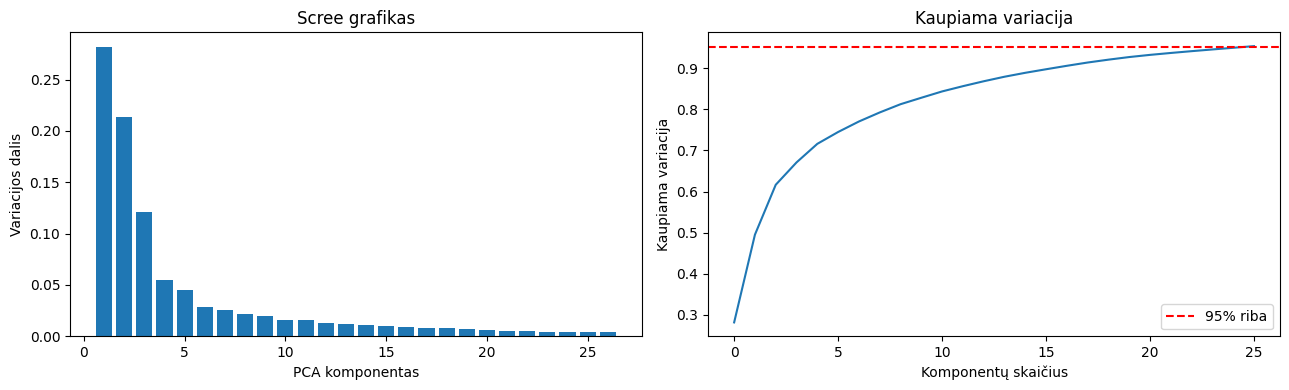

In [10]:
# Požymių analizė pagal grupes:
# Įkeliamas galutinis požymių failas ir prijungiami metaduomenys
# Susumuojami požymiai pagal tipus (entropija, alfa, teta ir t.t.)
# Brėžiamos box plot diagramos kiekvienam požymių tipui
# Naudojami lietuviški pavadinimai ašių ir pavadinimų etiketėms
df = pd.read_csv('EEG_Features_Final.csv')

# Tik spektriniai požymiai — kliniškai prasmingesni AD/FTD atskyrymui
spectral_cols = [c for c in df.columns if any(x in c for x in
    ['alpha', 'theta', 'delta', 'beta', 'gamma', 'sef95', 'median_freq', 'hjorth_mobility', 'hjorth_complexity'])]
print(spectral_cols)
X = df[spectral_cols]
print(f'Spektrinių požymių skaičius: {X.shape[1]}')

# 1. Apkirpimas
X_clipped = np.clip(X,
    np.percentile(X, 1,  axis=0),
    np.percentile(X, 99, axis=0)
)

# 2. Skalinimas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clipped)

# 3. Outlier pašalinimas
pca_check = PCA(n_components=10, random_state=42)
X_check   = pca_check.fit_transform(X_scaled)
distances = np.sqrt(np.sum(X_check**2, axis=1))
threshold = np.percentile(distances, 95)
mask      = distances < threshold

X_clean = X_scaled[mask]
y       = df_meta['Group'].values[mask]  # grupių etiketės su tuo pačiu mask
print(f'Pašalinta outlierių: {(~mask).sum()}, liko subjektų: {mask.sum()}')

# 4. PCA
pca   = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_clean)
print(f'Po PCA: {X_pca.shape[1]} komponentai paaiškina 95% dispersijos')

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
axes[0].set_xlabel('PCA komponentas'); axes[0].set_ylabel('Variacijos dalis')
axes[0].set_title('Scree grafikas')

axes[1].plot(np.cumsum(pca.explained_variance_ratio_))
axes[1].axhline(0.95, color='red', linestyle='--', label='95% riba')
axes[1].set_xlabel('Komponentų skaičius'); axes[1].set_ylabel('Kaupiama variacija')
axes[1].set_title('Kaupiama variacija'); axes[1].legend()
plt.tight_layout(); plt.show()

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_clean)


---
## 7. PCA — Dimensijų Mažinimas

Pagrindinių komponenčių analizė (PCA) naudojama požymių erdvei sutrumpinti, išsaugant **95% dispersijos**.




PCA LOADINGS (pirmi 5 PC):
                           PC1       PC2       PC3       PC4       PC5
C3_hjorth_mobility    0.088537 -0.024546  0.185463 -0.108754  0.051799
C3_hjorth_complexity -0.040257  0.072526  0.158443 -0.115871  0.177016
C3_delta_rel         -0.066313 -0.068083  0.067583  0.048586  0.133091
C3_theta_rel         -0.061915 -0.151400  0.103417  0.017935 -0.119866
C3_alpha_rel          0.120586 -0.149182 -0.014007 -0.048832  0.085617
...                        ...       ...       ...       ...       ...
DIFF_median_freq     -0.005446 -0.024584 -0.172081  0.129526  0.102421
F_mean_sef95          0.045085  0.166166  0.114724 -0.067645 -0.039743
O_mean_sef95          0.035300  0.154347  0.088885  0.185445 -0.038648
O_std_sef95          -0.032007  0.040689  0.017331 -0.015861  0.116174
DIFF_sef95           -0.005218  0.013106 -0.016387  0.340469 -0.008763

[112 rows x 5 columns]

🔥 PC1 TOP 5 features:

+ Positive loadings:
P3_hjorth_mobility    0.160458
P4_hjorth_mobility  

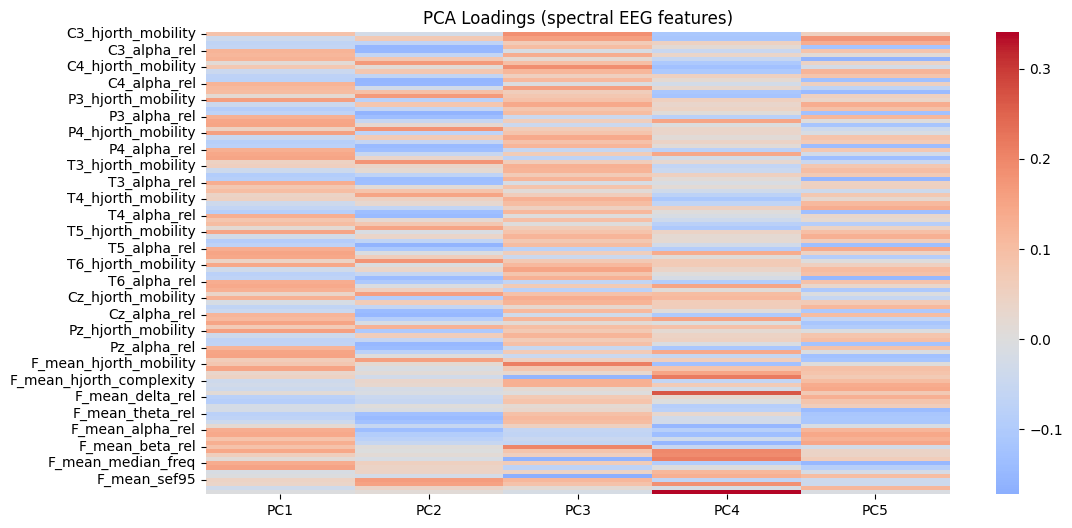

In [11]:
# PCA dimensijų mažinimas:
# Atrenkamos tik spektrinės ir Hjorth požymių kolonos
# Duomenys apkarpomi ties 1 ir 99 procentiliais išskirčių kontrolei
# Duomenys standartizuojami (vidurkis=0, std=1)
# Atliekamas preliminarus PCA outlierių aptikimui — pašalinami 5% kraštiniai taškai
# PCA taikomas išsaugant 95% dispersijos
# Brėžiamas scree grafikas ir kaupiamos variacijos kreivė
# =====================================
# PCA LOADINGS (INTERPRETACIJA)
# =====================================
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=spectral_cols
)

print("\nPCA LOADINGS (pirmi 5 PC):")
print(loadings.iloc[:, :5])

# =====================================
# TOP FEATURES kiekvienam PC
# =====================================
n_top = 5

for pc in loadings.columns[:5]:
    print(f"\n🔥 {pc} TOP {n_top} features:")

    top_pos = loadings[pc].sort_values(ascending=False).head(n_top)
    top_neg = loadings[pc].sort_values().head(n_top)

    print("\n+ Positive loadings:")
    print(top_pos)

    print("\n- Negative loadings:")
    print(top_neg)
plt.figure(figsize=(12, 6))

sns.heatmap(
    loadings.iloc[:, :5],
    cmap="coolwarm",
    center=0
)

plt.title("PCA Loadings (spectral EEG features)")
plt.show()

### PCA Loadings — Požymių Svarba

Kiekvienam pagrindiniam komponentui (PC) analizuojama, kurie požymiai turi didžiausią įtaką.


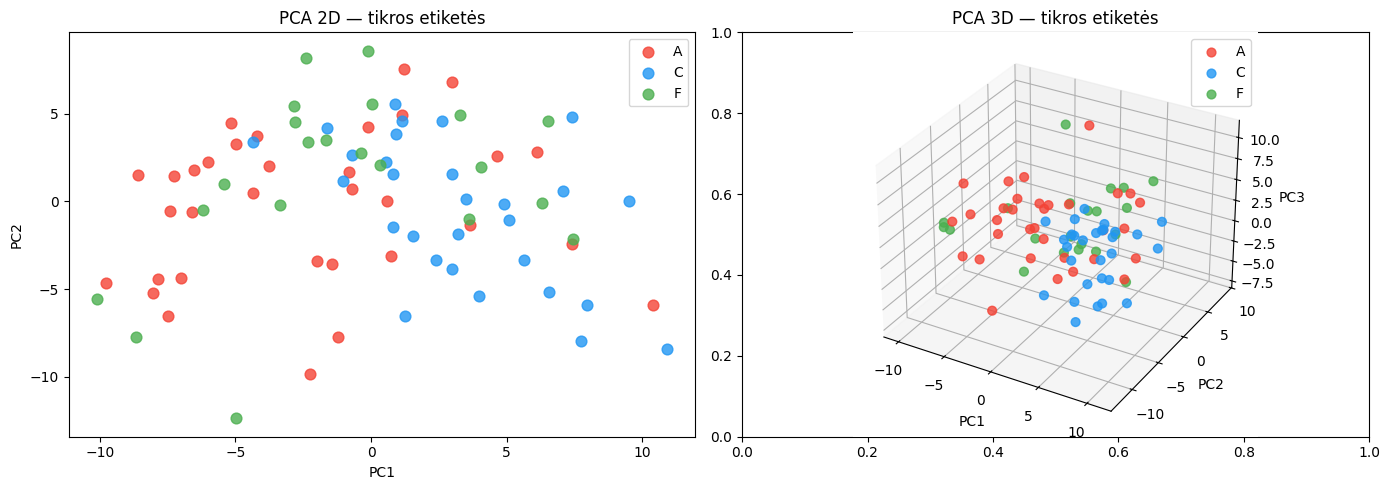

In [12]:
# PCA loadings analizė:
# Kiekvienam pagrindiniam komponentui (PC) apskaičiuojami loadings
# Parodomi 5 didžiausią teigiamą ir neigiamą įtaką turintys požymiai
# Brėžiamas heatmap visų PC loadings vizualizavimui
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2D
for grp, color in zip(['A', 'C', 'F'], ['#F44336', '#2196F3', '#4CAF50']):
    idx = y == grp
    axes[0].scatter(X_pca[idx, 0], X_pca[idx, 1], label=grp, color=color, s=60, alpha=0.8)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title('PCA 2D — tikros etiketės'); axes[0].legend()

# 3D
ax3d = fig.add_subplot(122, projection='3d')
for grp, color in zip(['A', 'C', 'F'], ['#F44336', '#2196F3', '#4CAF50']):
    idx = y == grp
    ax3d.scatter(X_pca[idx, 0], X_pca[idx, 1], X_pca[idx, 2],
                 label=grp, color=color, s=40, alpha=0.8)
ax3d.set_xlabel('PC1'); ax3d.set_ylabel('PC2'); ax3d.set_zlabel('PC3')
ax3d.set_title('PCA 3D — tikros etiketės'); ax3d.legend()
plt.tight_layout(); plt.show()

### PCA Vizualizacija su Tikromis Etiketėmis

2D ir 3D projekcijos spalvotos pagal tikrą grupę — leidžia vizualiai įvertinti grupių atskiriamumą.


K-Means Silhouette: 0.18501616409109145


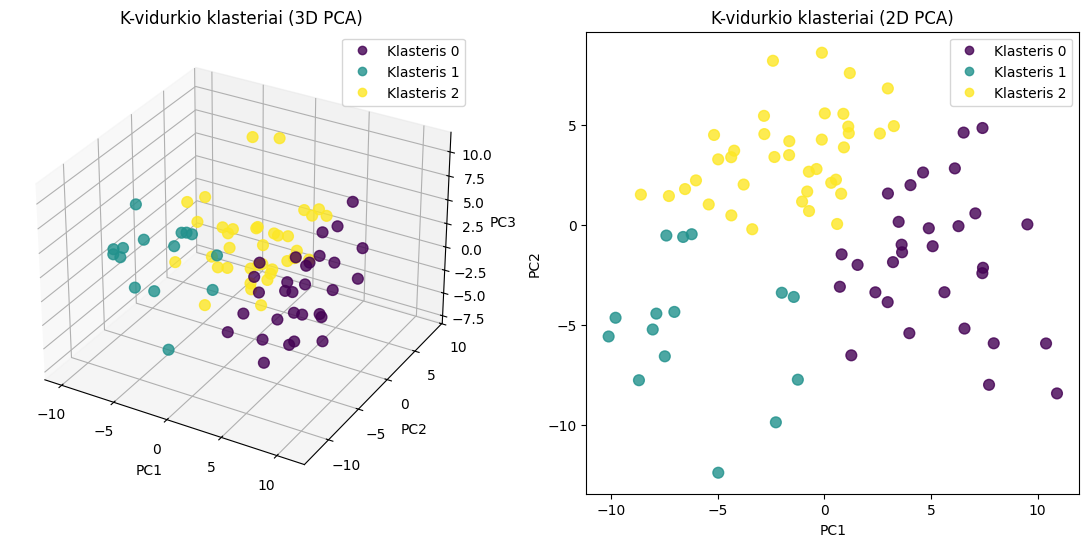

In [13]:
# PCA rezultatų vizualizacija su tikromis grupių etiketėmis:
# 2D ir 3D taškinės diagramos spalvotos pagal tikrą grupę (A/C/F)
# Galutinis K-Means su k=3
kmeans = KMeans(n_clusters=3, random_state=250)
clusters_kmeans = kmeans.fit_predict(X_pca)
print('K-Means Silhouette:', silhouette_score(X_pca, clusters_kmeans))

fig = plt.figure(figsize=(14, 6))

# -------------------------
# 2D PCA
# -------------------------
ax1 = fig.add_subplot(1, 2, 2)

scatter1 = ax1.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_kmeans,
    cmap='viridis',
    s=60,
    alpha=0.8
)
handles1, _ = scatter1.legend_elements()
ax1.legend(handles1, [f'Klasteris {i}' for i in range(3)])

ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('K-vidurkio klasteriai (2D PCA)')


# -------------------------
# 3D PCA
# -------------------------
ax2 = fig.add_subplot(1, 2, 1, projection='3d')

scatter2 = ax2.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=clusters_kmeans,
    cmap='viridis',
    s=60,
    alpha=0.8
)
handles2, _ = scatter2.legend_elements()
ax2.legend(handles2, [f'Klasteris {i}' for i in range(3)])
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title('K-vidurkio klasteriai (3D PCA)')

plt.show()

---
## 8. Klasterizavimas

Taikomi trys skirtingi klasterizavimo metodai PCA erdvėje, siekiant palyginti jų efektyvumą.

### 8.1 K-Means


GMM Silhouette: 0.17744204269819222
GMM Log-likelihood: -18.488277537571086


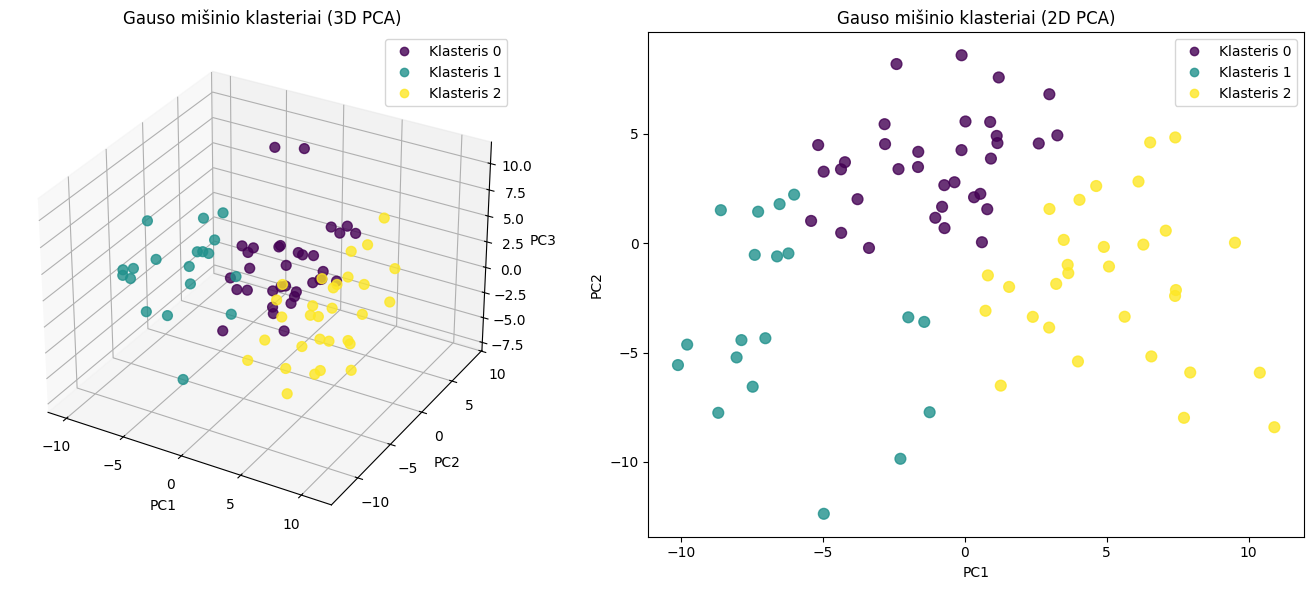

In [14]:
# K-vidurkių klasterizavimas ant PCA erdvės:
# k=3 klasteriai atitinka tris grupes (AD, FTD, Control)
# n_init=50 — paleisti 50 kartų su skirtingais pradiniais centrais
# Brėžiamos 2D ir 3D vizualizacijos su klasterių spalvomis
# Geriausias covariance tipas per BIC
gmm = GaussianMixture(n_components=3, random_state=160)
gmm.fit(X_pca)
clusters_gmm = gmm.predict(X_pca)
print('GMM Silhouette:', silhouette_score(X_pca, clusters_gmm))
print('GMM Log-likelihood:', gmm.score(X_pca))

# =========================
# FIGURE: 2D + 3D
# =========================
fig = plt.figure(figsize=(14, 6))

# -------------------------
# 2D PCA
# -------------------------
ax1 = fig.add_subplot(1, 2, 2)

scatter1 = ax1.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_gmm,
    cmap='viridis',
    s=60,
    alpha=0.8
)

ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('Gauso mišinio klasteriai (2D PCA)')

handles1, _ = scatter1.legend_elements()
ax1.legend(handles1, [f'Klasteris {i}' for i in range(3)])


# -------------------------
# 3D PCA
# -------------------------
ax2 = fig.add_subplot(1, 2, 1, projection='3d')

scatter2 = ax2.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=clusters_gmm,
    cmap='viridis',
    s=50,
    alpha=0.8
)

ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title('Gauso mišinio klasteriai (3D PCA)')

handles2, _ = scatter2.legend_elements()
ax2.legend(handles2, [f'Klasteris {i}' for i in range(3)])

plt.tight_layout()
plt.show()

### 8.2 Gauso Mišinių Modelis (GMM)


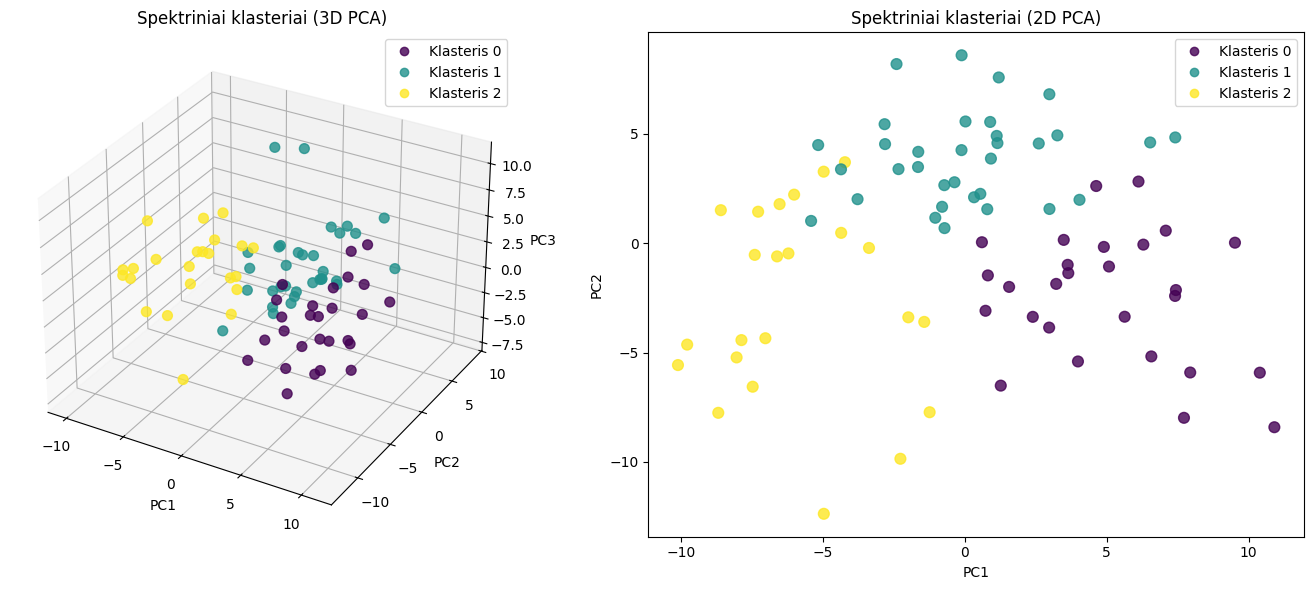

Spectral Silhouette: 0.16879364699322247


In [15]:
# Gauso mišinių modelis (GMM):
# Alternatyvus probabilistinis klasterizavimo metodas
# Leidžia lanksčias elipsines klasterių formas
# Vertinama Log-likelihood reikšmė modelio kokybei
# Brėžiamos 2D ir 3D vizualizacijos
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

spectral = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors",
    random_state=100
)

clusters_spectral = spectral.fit_predict(X_pca)

# =========================
# FIGURE: 2D + 3D
# =========================
fig = plt.figure(figsize=(14, 6))

# -------------------------
# 2D
# -------------------------
ax1 = fig.add_subplot(1, 2, 2)

scatter1 = ax1.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_spectral,
    cmap="viridis",
    s=60,
    alpha=0.8
)

ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_title("Spektriniai klasteriai (2D PCA)")

handles1, _ = scatter1.legend_elements()
ax1.legend(handles1, [f"Klasteris {i}" for i in range(3)])


# -------------------------
# 3D
# -------------------------
ax2 = fig.add_subplot(1, 2, 1, projection='3d')

scatter2 = ax2.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=clusters_spectral,
    cmap="viridis",
    s=50,
    alpha=0.8
)

ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
ax2.set_title("Spektriniai klasteriai (3D PCA)")

handles2, _ = scatter2.legend_elements()
ax2.legend(handles2, [f"Klasteris {i}" for i in range(3)])

plt.tight_layout()
plt.show()


print("Spectral Silhouette:", silhouette_score(X_pca, clusters_spectral))

### 8.3 Spektrinis Klasterizavimas


In [16]:
# Spektrinis klasterizavimas:
# Naudoja artimiausių kaimynų grafo struktūrą
# Gali aptikti netiesinius klasterių pavidalus
# Brėžiamos 2D ir 3D vizualizacijos
le = LabelEncoder()
y_enc = le.fit_transform(y)

def evaluate_clustering(y_true, clusters, name):
    cm = confusion_matrix(y_true, clusters)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = dict(zip(col_ind, row_ind))
    mapped  = np.array([mapping[c] for c in clusters])

    from sklearn.metrics import accuracy_score, jaccard_score
    acc = accuracy_score(y_true, mapped)
    jac = jaccard_score(y_true, mapped, average='macro')
    sil = silhouette_score(X_pca, clusters)

    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print(f'Jaccard:              {jac:.4f}')
    print(f'Silhouette:           {sil:.4f}')
    print('\nKonfuzijos matrica:')
    print(confusion_matrix(y_true, mapped))

    df_cross = pd.DataFrame({'Klasteris': clusters, 'Grupė': y})
    print('\nKlasterių sudėtis:')
    print(pd.crosstab(df_cross['Klasteris'], df_cross['Grupė']))

evaluate_clustering(y_enc, clusters_kmeans, 'K-Means')
evaluate_clustering(y_enc, clusters_gmm,    'GMM')
evaluate_clustering(y_enc, clusters_spectral,    'Spectral')


=== K-Means ===
Accuracy: 0.5060
Jaccard:              0.3425
Silhouette:           0.1850

Konfuzijos matrica:
[[11  6 16]
 [ 0 19 10]
 [ 4  5 12]]

Klasterių sudėtis:
Grupė       A   C   F
Klasteris            
0           6  19   5
1          11   0   4
2          16  10  12

=== GMM ===
Accuracy: 0.5542
Jaccard:              0.3865
Silhouette:           0.1774

Konfuzijos matrica:
[[15  6 12]
 [ 0 19 10]
 [ 4  5 12]]

Klasterių sudėtis:
Grupė       A   C   F
Klasteris            
0          12  10  12
1          15   0   4
2           6  19   5

=== Spectral ===
Accuracy: 0.5783
Jaccard:              0.4089
Silhouette:           0.1688

Konfuzijos matrica:
[[18  7  8]
 [ 0 17 12]
 [ 5  3 13]]

Klasterių sudėtis:
Grupė       A   C   F
Klasteris            
0           7  17   3
1           8  12  13
2          18   0   5


### 8.4 Klasterizavimo Vertinimas


In [17]:
# Klasterizavimo vertinimo funkcija:
# Vengrų algoritmu surandamas optimalus klasterių ir grupių atitikmenys
# Skaičiuojami trys metrikų rodikliai:
# - Accuracy: teisingai priskirtų tiriamųjų dalis
# - Jaccard: klasterių ir tikrų grupių sutapimo indeksas
# - Silhouette: klasterių kompaktiškumo ir atskyrimo rodiklis
# Spausdinama konfuzijos matrica ir klasterių sudėtis
le = LabelEncoder()

def evaluate_clustering(y_true, clusters, X_data, name):
    cm = confusion_matrix(y_true, clusters)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = dict(zip(col_ind, row_ind))
    mapped  = np.array([mapping[c] for c in clusters])

    acc = accuracy_score(y_true, mapped)
    jac = jaccard_score(y_true, mapped, average='macro')
    sil = silhouette_score(X_data, clusters)

    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print(f'Jaccard: {jac:.4f}')
    print(f'Silhouette: {sil:.4f}')
    print('\nKonfuzijos matrica:')
    print(confusion_matrix(y_true, mapped))

    df_cross = pd.DataFrame({'Klasteris': clusters, 'Grupė': y_true})
    print('\nKlasterių sudėtis:')
    print(pd.crosstab(df_cross['Klasteris'], df_cross['Grupė']))

---
## 9. Porinė Analizė

Siekiant detalesnio grupių atskyrumo įvertinimo, atliekama atskirų porų analizė:

- 🔴 **AD vs C** — Alzheimerio liga prieš sveikus
- 🔵 **C vs FTD** — Sveiki prieš frontotemporalinę demenciją  
- 🟢 **AD vs FTD** — Abiejų demencijų tipų palyginimas

Kiekvienai porai taikomi visi trys klasterizavimo metodai.



ANALIZĖ: A vs C


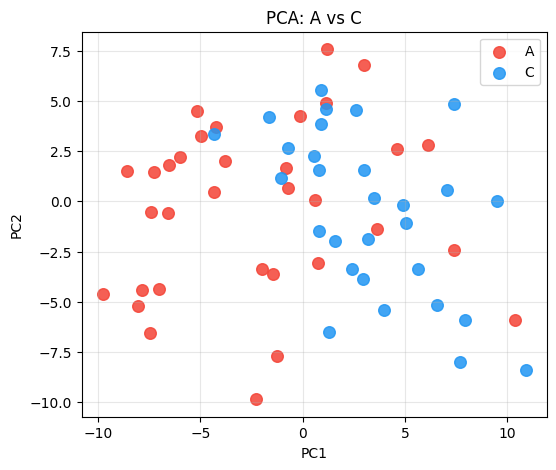

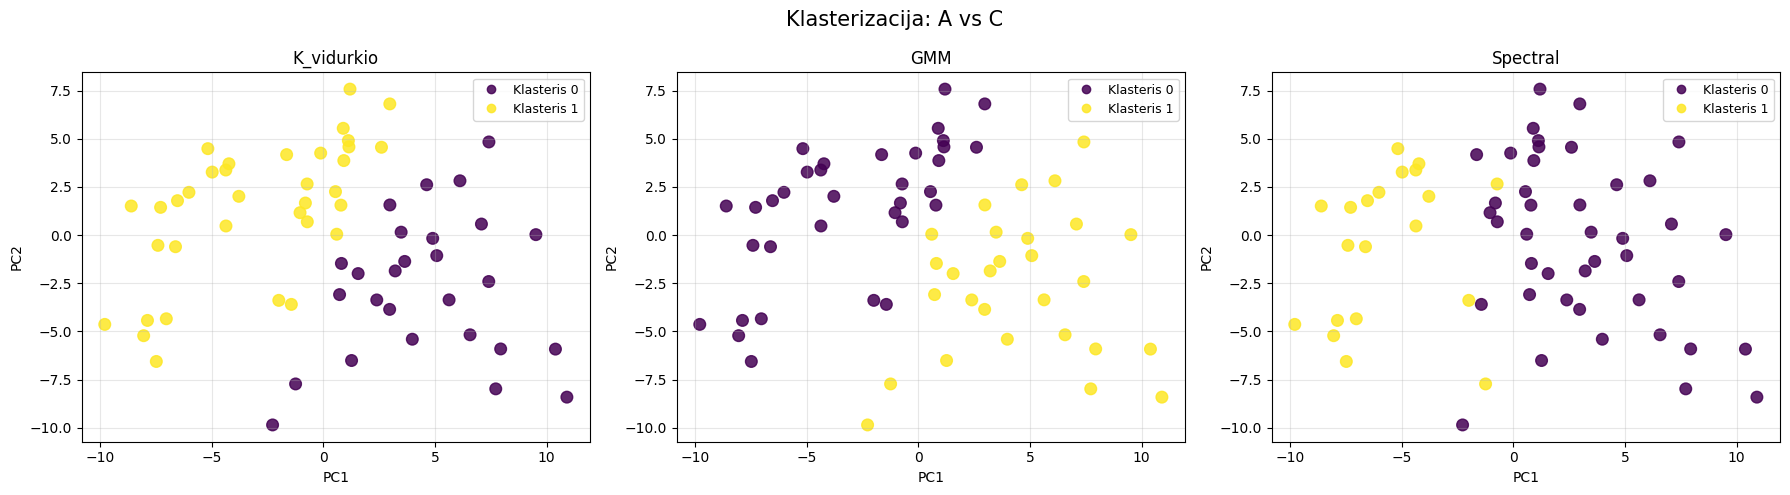


=== A-C K-vidurkio ===
Accuracy: 0.7097
Jaccard: 0.5475
Silhouette: 0.1849

Konfuzijos matrica:
[[25  8]
 [10 19]]

Klasterių sudėtis:
Grupė       0   1
Klasteris        
0           8  19
1          25  10

=== A-C GMM ===
Accuracy: 0.6935
Jaccard: 0.5291
Silhouette: 0.1837

Konfuzijos matrica:
[[24  9]
 [10 19]]

Klasterių sudėtis:
Grupė       0   1
Klasteris        
0          24  10
1           9  19

=== A-C Spectral ===
Accuracy: 0.7258
Jaccard: 0.5640
Silhouette: 0.1980

Konfuzijos matrica:
[[18 15]
 [ 2 27]]

Klasterių sudėtis:
Grupė       0   1
Klasteris        
0          15  27
1          18   2

ANALIZĖ: C vs F


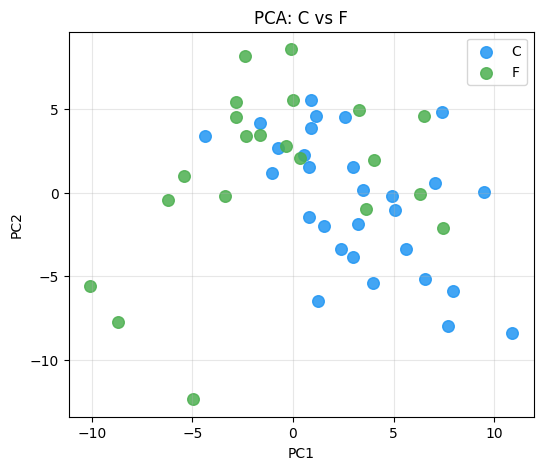

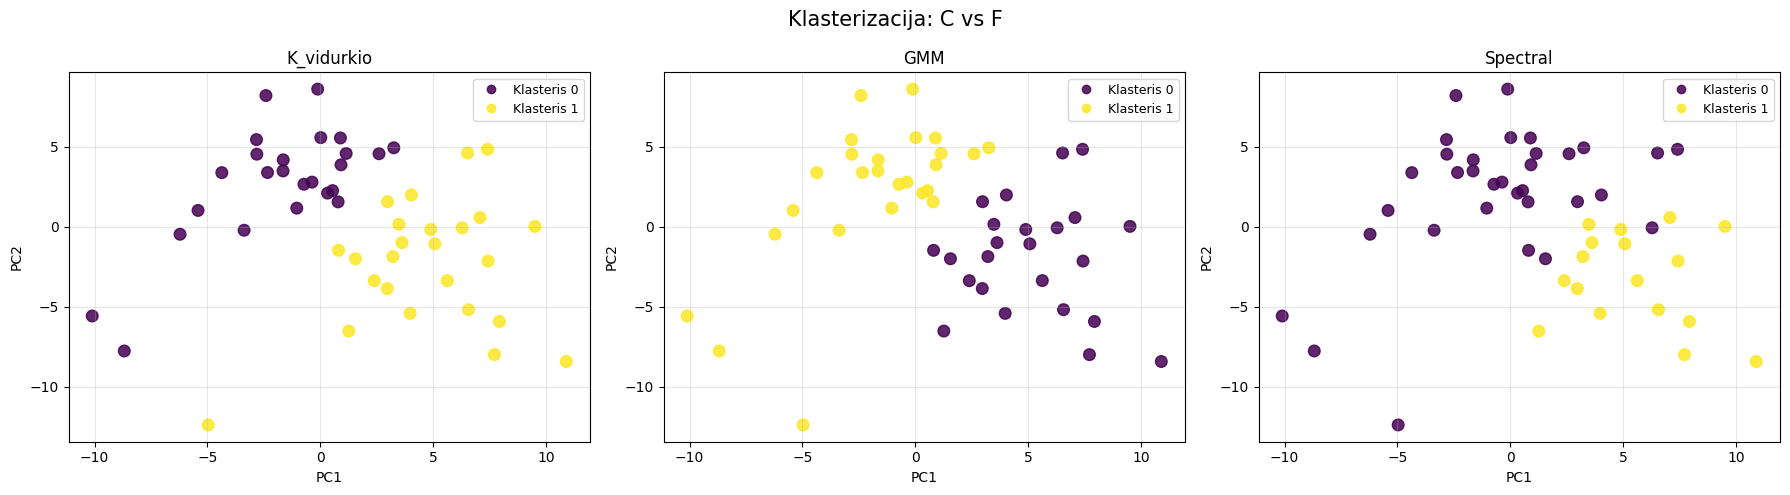


=== C-F K-vidurkio ===
Accuracy: 0.6800
Jaccard: 0.5134
Silhouette: 0.1856

Konfuzijos matrica:
[[19 10]
 [ 6 15]]

Klasterių sudėtis:
Grupė       0   1
Klasteris        
0          10  15
1          19   6

=== C-F GMM ===
Accuracy: 0.7000
Jaccard: 0.5375
Silhouette: 0.1825

Konfuzijos matrica:
[[19 10]
 [ 5 16]]

Klasterių sudėtis:
Grupė       0   1
Klasteris        
0          19   5
1          10  16

=== C-F Spectral ===
Accuracy: 0.6800
Jaccard: 0.5134
Silhouette: 0.1631

Konfuzijos matrica:
[[15 14]
 [ 2 19]]

Klasterių sudėtis:
Grupė       0   1
Klasteris        
0          14  19
1          15   2

ANALIZĖ: A vs F


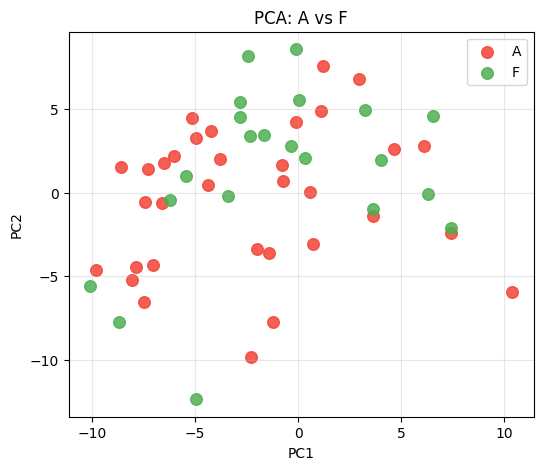

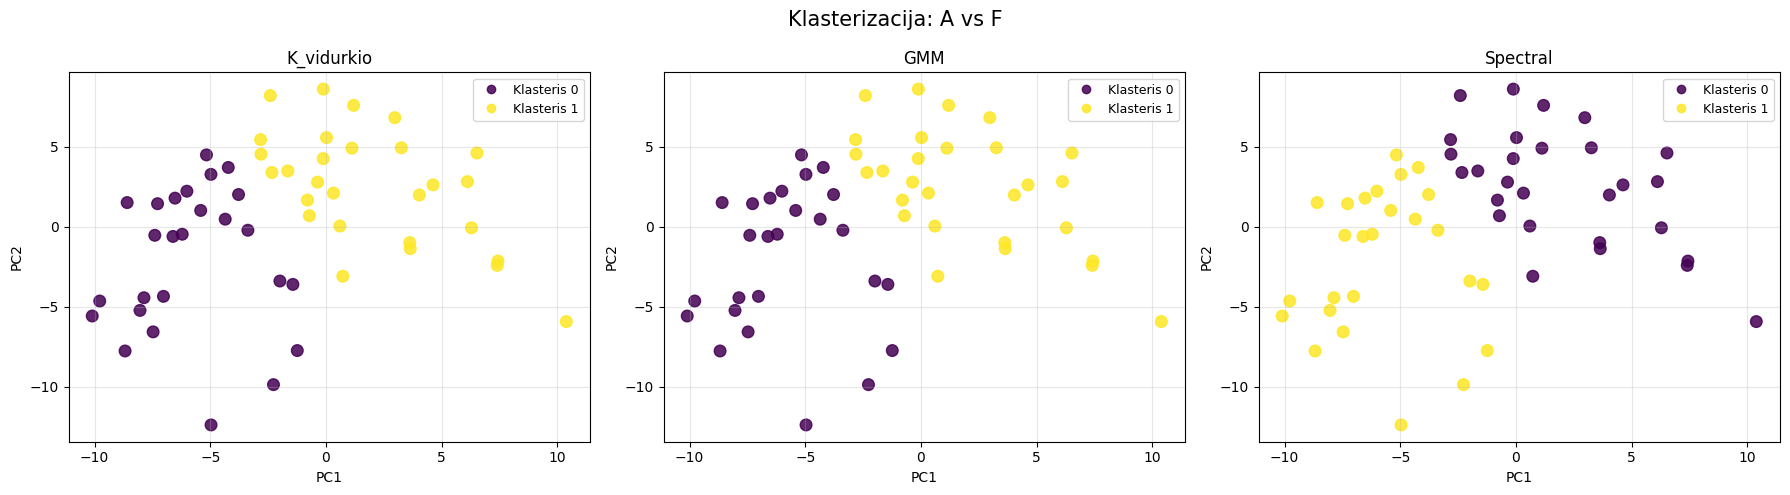


=== A-F K-vidurkio ===
Accuracy: 0.6481
Jaccard: 0.4770
Silhouette: 0.2034

Konfuzijos matrica:
[[20 13]
 [ 6 15]]

Klasterių sudėtis:
Grupė       0   1
Klasteris        
0          20   6
1          13  15

=== A-F GMM ===
Accuracy: 0.6481
Jaccard: 0.4770
Silhouette: 0.2034

Konfuzijos matrica:
[[20 13]
 [ 6 15]]

Klasterių sudėtis:
Grupė       0   1
Klasteris        
0          20   6
1          13  15

=== A-F Spectral ===
Accuracy: 0.6481
Jaccard: 0.4770
Silhouette: 0.2034

Konfuzijos matrica:
[[20 13]
 [ 6 15]]

Klasterių sudėtis:
Grupė       0   1
Klasteris        
0          13  15
1          20   6


In [18]:
# Porinė analizė kiekvienai dviejų grupių kombinacijai:
# Atliekama atskirai: AD vs Control, Control vs FTD, AD vs FTD
# Kiekvienai porai taikomi visi trys klasterizavimo metodai
# Brėžiamos PCA vizualizacijos su tikromis etiketėmis ir klasteriais
# Vertinami Accuracy, Jaccard ir Silhouette rodikliai
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

pairs = [
    ('A', 'C'),
    ('C', 'F'),
    ('A', 'F')
]

colors = {
    'A': '#F44336',
    'C': '#2196F3',
    'F': '#4CAF50'
}

# ============================================
# FUNKCIJA PORINEI ANALIZEI
# ============================================

def run_pair_analysis(group1, group2):

    print(f'\n==============================')
    print(f'ANALIZĖ: {group1} vs {group2}')
    print(f'==============================')

    # ----------------------------------------
    # Grupių filtravimas
    # ----------------------------------------
    mask_pair = np.isin(y, [group1, group2])

    X_pair = X_scaled[mask][mask_pair]
    y_pair = y[mask_pair]
    
    X_pca_pair = X_pca[mask_pair]

    # ----------------------------------------
    # PCA TRUE LABELS
    # ----------------------------------------

    plt.figure(figsize=(6,5))

    for grp in [group1, group2]:
        idx = y_pair == grp

        plt.scatter(
            X_pca_pair[idx, 0],
            X_pca_pair[idx, 1],
            label=grp,
            color=colors[grp],
            s=70,
            alpha=0.85
        )

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'PCA: {group1} vs {group2}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # ========================================
    # KLASTERIZAVIMO METODAI
    # ========================================

    clustering_results = {}

    # ----------------------------------------
    # KMEANS
    # ----------------------------------------

    kmeans = KMeans(
        n_clusters=2,
        n_init=50,
        random_state=42
    )

    clustering_results['K_vidurkio'] = kmeans.fit_predict(X_pca_pair)

    # ----------------------------------------
    # GMM
    # ----------------------------------------

    gmm = GaussianMixture(
        n_components=2,
        random_state=42
    )

    clustering_results['GMM'] = gmm.fit_predict(X_pca_pair)

    # ----------------------------------------
    # SPECTRAL
    # ----------------------------------------

    spectral = SpectralClustering(
        n_clusters=2,
        affinity='nearest_neighbors',
        random_state=42
    )

    clustering_results['Spectral'] = spectral.fit_predict(X_pca_pair)

    # ========================================
    # SUBPLOTS 1x3
    # ========================================

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (name, clusters) in zip(axes, clustering_results.items()):

        scatter = ax.scatter(
            X_pca_pair[:, 0],
            X_pca_pair[:, 1],
            c=clusters,
            cmap='viridis',
            s=70,
            alpha=0.85
        )

        sil = silhouette_score(X_pca_pair, clusters)
        handles, labels = scatter.legend_elements()
        ax.legend(handles, [f'Klasteris {i}' for i in range(2)],
          loc='upper right',
          fontsize=9)
        ax.set_title(f'{name}')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.grid(alpha=0.3)

    plt.suptitle(f'Klasterizacija: {group1} vs {group2}', fontsize=15)
    plt.tight_layout()
    plt.show()

    y_enc = le.fit_transform(y_pair)
    
    evaluate_clustering(y_enc, clustering_results['K_vidurkio'], X_pca_pair, f"{group1}-{group2} K-vidurkio")
    evaluate_clustering(y_enc, clustering_results['GMM'], X_pca_pair, f"{group1}-{group2} GMM")
    evaluate_clustering(y_enc, clustering_results['Spectral'], X_pca_pair, f"{group1}-{group2} Spectral")
# ============================================
# PALEIDIMAS VISOMS POROMS
# ============================================

for g1, g2 in pairs:
    run_pair_analysis(g1, g2)

---
## 10. PCA vs t-SNE Palyginimas

t-SNE shape: (83, 2)


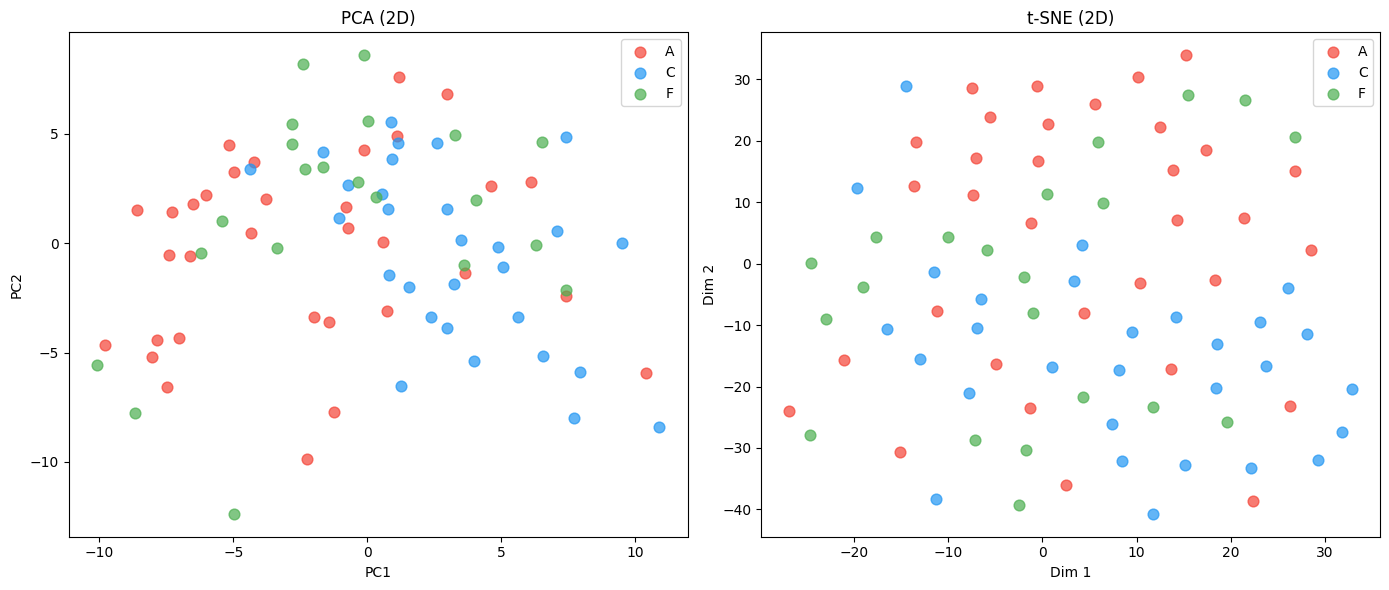

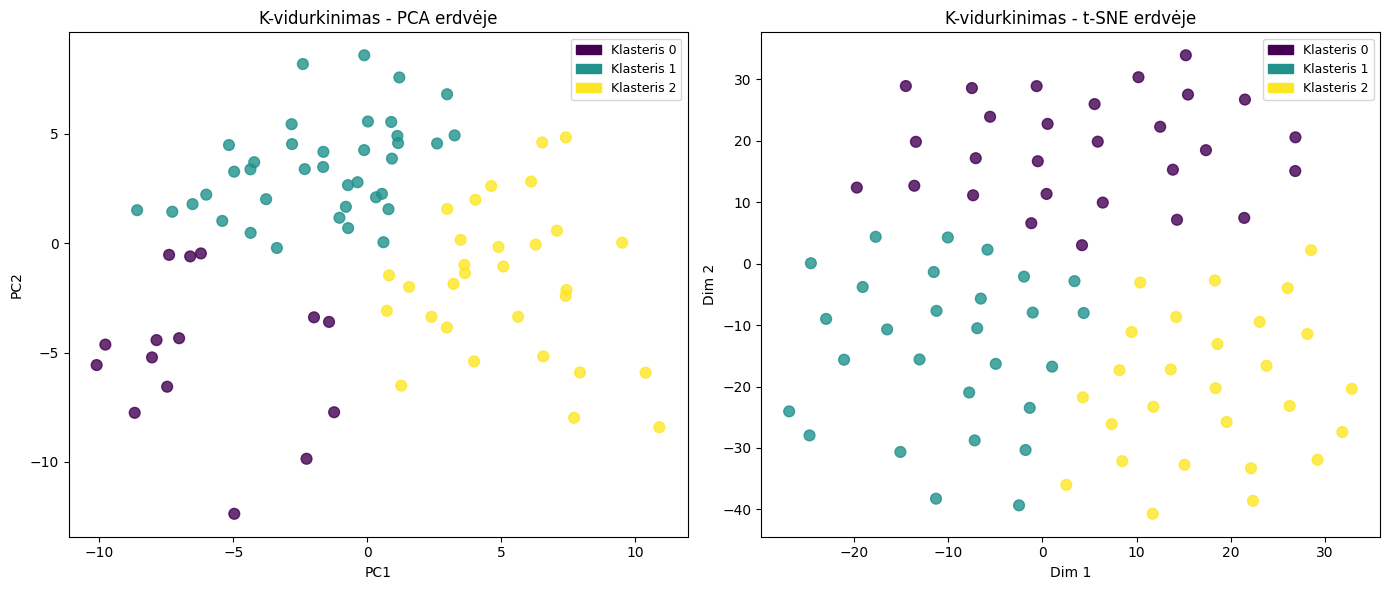


===== Silhouette comparison =====
PCA space:   0.1850
t-SNE space: 0.3914


In [19]:
# t-SNE dimensijų mažinimas ir palyginimas su PCA:
# t-SNE taikomas ant jau sumažintos PCA erdvės
# perplexity=30, learning_rate=200 — standartiniai parametrai
# PCA ir t-SNE projekcijos lyginamos vizualiai
# K-vidurkiai taikomi abiejose erdvėse
# Silhouette koeficientai lyginami tarp PCA ir t-SNE erdvių
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. t-SNE (ant PCA erdvės)
# =========================
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

print("t-SNE shape:", X_tsne.shape)


# =========================
# 2. Vizualizacija: PCA vs t-SNE
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

groups = ['A', 'C', 'F']
colors = ['#F44336', '#2196F3', '#4CAF50']

# ---------------- PCA ----------------
for grp, color in zip(groups, colors):
    idx = y == grp
    axes[0].scatter(
        X_pca[idx, 0], X_pca[idx, 1],
        label=grp, color=color, s=60, alpha=0.7
    )

axes[0].set_title("PCA (2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

# ---------------- t-SNE ----------------
for grp, color in zip(groups, colors):
    idx = y == grp
    axes[1].scatter(
        X_tsne[idx, 0], X_tsne[idx, 1],
        label=grp, color=color, s=60, alpha=0.7
    )

axes[1].set_title("t-SNE (2D)")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")
axes[1].legend()

plt.tight_layout()
plt.show()


# =========================
# 3. KMeans abiejose erdvėse
# =========================

# PCA space
kmeans_pca = KMeans(n_clusters=3, n_init=50, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# t-SNE space
kmeans_tsne = KMeans(n_clusters=3, n_init=50, random_state=42)
clusters_tsne = kmeans_tsne.fit_predict(X_tsne)


# =========================
# 4. Clustering vizualizacija
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

import matplotlib.patches as mpatches

handles = [
    mpatches.Patch(color=plt.cm.viridis(i / 2), label=f'Klasteris {i}')
    for i in range(3)
]

axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=clusters_pca, cmap='viridis', s=60, alpha=0.8
)
axes[0].legend(
    handles,
    [f'Klasteris {i}' for i in range(3)],
    loc='upper right',
    fontsize=9)
axes[0].set_title("K-vidurkinimas - PCA erdvėje")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=clusters_tsne, cmap='viridis', s=60, alpha=0.8
)
axes[1].legend(
    handles,
    [f'Klasteris {i}' for i in range(3)],
    loc='upper right',
    fontsize=9)
axes[1].set_title("K-vidurkinimas - t-SNE erdvėje")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")

plt.tight_layout()
plt.show()


# =========================
# 5. Silhouette palyginimas
# =========================
sil_pca = silhouette_score(X_pca, clusters_pca)
sil_tsne = silhouette_score(X_tsne, clusters_tsne)

print("\n===== Silhouette comparison =====")
print(f"PCA space:   {sil_pca:.4f}")
print(f"t-SNE space: {sil_tsne:.4f}")

---
## 11. Galutinis Vertinimas — PCA vs t-SNE

K-Means klasterizavimo rezultatų palyginimas abiejose dimensijų mažinimo erdvėse.


In [20]:
# Galutinis K-vidurkių vertinimas PCA ir t-SNE erdvėse:
# Vengrų algoritmu sulyginamos klasterių ir grupių etiketės
# Lyginami Accuracy, Jaccard ir Silhouette abiejose erdvėse
# Spausdinamos konfuzijos matricos ir klasterių sudėtys
from sklearn.metrics import confusion_matrix, silhouette_score, accuracy_score, jaccard_score
from sklearn.preprocessing import LabelEncoder
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

# =========================
# Label encoding
# =========================
le = LabelEncoder()
y_enc = le.fit_transform(y)

# =========================
# Evaluation funkcija
# =========================
def evaluate_embedding(y_true, clusters, X_embedded, name):

    # --- Confusion matrix + Hungarian matching ---
    cm = confusion_matrix(y_true, clusters)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = dict(zip(col_ind, row_ind))
    mapped = np.array([mapping[c] for c in clusters])

    # --- Metrics ---
    acc = accuracy_score(y_true, mapped)
    jac = jaccard_score(y_true, mapped, average='macro')
    sil = silhouette_score(X_embedded, clusters)

    print(f"\n===== {name} =====")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Jaccard:     {jac:.4f}")
    print(f"Silhouette:  {sil:.4f}")

    print("\nConfusion matrix (after matching):")
    print(confusion_matrix(y_true, mapped))

    # --- Cluster composition ---
    df_cross = pd.DataFrame({
        "Cluster": clusters,
        "TrueGroup": y
    })

    print("\nCluster composition:")
    print(pd.crosstab(df_cross["Cluster"], df_cross["TrueGroup"]))


# =========================
# KMeans ant PCA
# =========================
from sklearn.cluster import KMeans

kmeans_pca = KMeans(n_clusters=3, n_init=50, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# =========================
# KMeans ant t-SNE
# =========================
kmeans_tsne = KMeans(n_clusters=3, n_init=50, random_state=42)
clusters_tsne = kmeans_tsne.fit_predict(X_tsne)

# =========================
# EVALUATION
# =========================
evaluate_embedding(y_enc, clusters_pca, X_pca, "KMeans - PCA space")
evaluate_embedding(y_enc, clusters_tsne, X_tsne, "KMeans - t-SNE space")


===== KMeans - PCA space =====
Accuracy:    0.5060
Jaccard:     0.3425
Silhouette:  0.1850

Confusion matrix (after matching):
[[11  6 16]
 [ 0 19 10]
 [ 4  5 12]]

Cluster composition:
TrueGroup   A   C   F
Cluster              
0          11   0   4
1          16  10  12
2           6  19   5

===== KMeans - t-SNE space =====
Accuracy:    0.5783
Jaccard:     0.4042
Silhouette:  0.3914

Confusion matrix (after matching):
[[19  7  7]
 [ 3 17  9]
 [ 6  3 12]]

Cluster composition:
TrueGroup   A   C   F
Cluster              
0          19   3   6
1           7   9  12
2           7  17   3
